In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [14]:
df=pd.read_csv("../data/processed/tesla_feature_engineered.csv")

In [15]:
X = df.drop(['Date', 'target'], axis=1)
y=df['target']

In [16]:
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [18]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

In [19]:
X_train_scaled.to_csv(
    "../data/final/X_train.csv",
    index=False
)

In [20]:
X_test_scaled.to_csv(
    "../data/final/X_test.csv",
    index=False
)

In [21]:
y_train.to_csv(
    "../data/final/y_train.csv",
    index=False
)

In [22]:
y_test.to_csv(
    "../data/final/y_test.csv",
    index=False
)

In [54]:
X_train = pd.read_csv("../data/final/X_train.csv")
X_test = pd.read_csv("../data/final/X_test.csv")

y_train = pd.read_csv("../data/final/y_train.csv")
y_test = pd.read_csv("../data/final/y_test.csv")

Linear Regression


In [25]:
lr_model = LinearRegression()

In [26]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
y_pred = lr_model.predict(X_test)

In [28]:
mae = mean_absolute_error(y_test, y_pred)

In [29]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [30]:
r2 = r2_score(y_test, y_pred)

In [31]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5.760817637711485
RMSE: 8.0601256108937
R2 Score: 0.9691096394985051


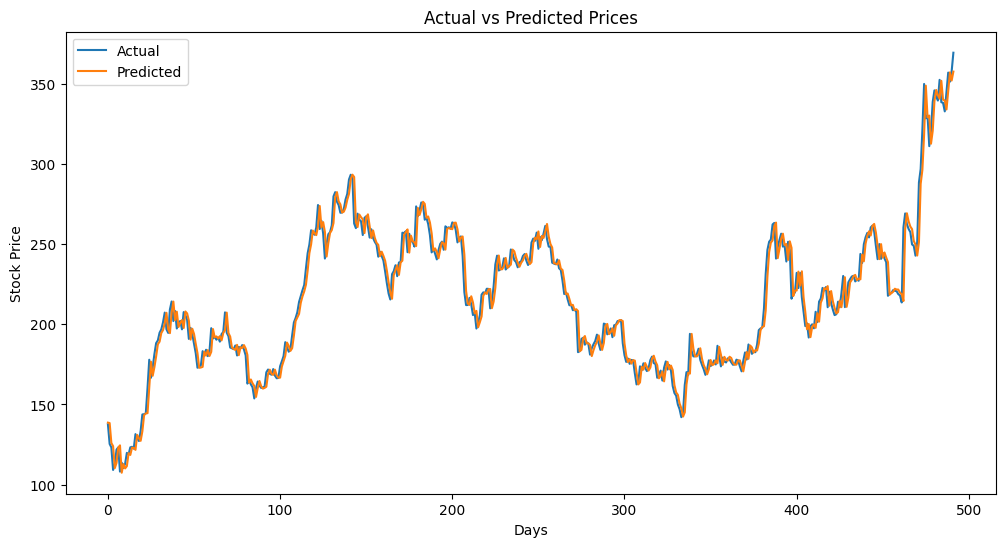

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.title("Actual vs Predicted Prices")
plt.xlabel("Days")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [33]:
#check for overfitting
train_pred = lr_model.predict(X_train)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.997449414459181
Test R2: 0.9691096394985051


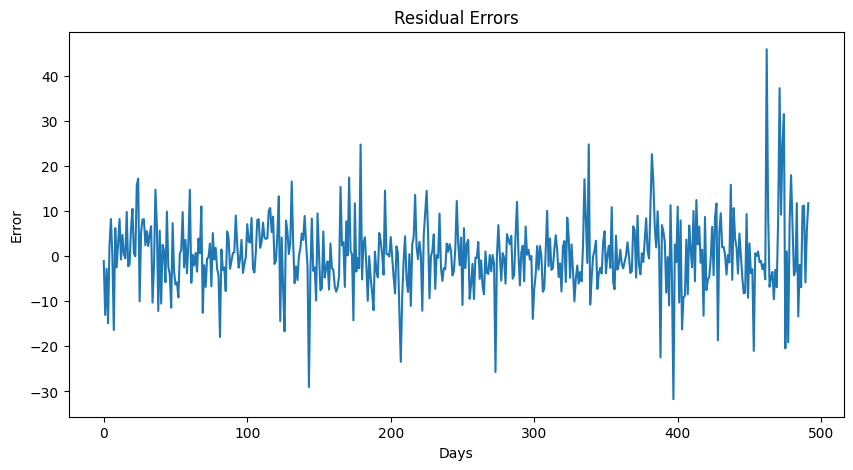

In [34]:
#Residual Analysis to check for overfitting
residuals = y_test - y_pred

plt.figure(figsize=(10,5))
plt.plot(residuals)

plt.title("Residual Errors")
plt.xlabel("Days")
plt.ylabel("Error")

plt.show()

Random Forest


In [36]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [37]:
rf_model.fit(X_train, y_train)

c:\Users\Maria\Documents\Projects\FinanceForecastingAnalysis\venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
rf_pred=rf_model.predict(X_test)

In [39]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

In [40]:
print("Random Forest MAE:", rf_mae)

print("Random Forest RMSE:", rf_rmse)

print("Random Forest R2:", rf_r2)

Random Forest MAE: 6.710856613821137
Random Forest RMSE: 9.266448712890863
Random Forest R2: 0.9591712569978208


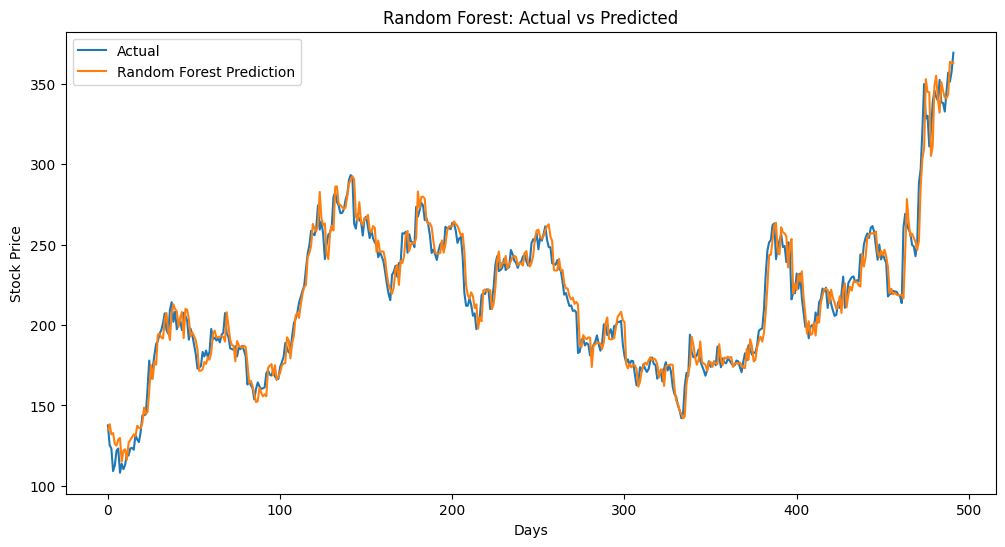

In [41]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')

plt.plot(rf_pred, label='Random Forest Prediction')

plt.title("Random Forest: Actual vs Predicted")

plt.xlabel("Days")

plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [42]:
rf_train_pred = rf_model.predict(X_train)

In [43]:
rf_train_r2 = r2_score(y_train, rf_train_pred)

rf_test_r2 = r2_score(y_test, rf_pred)

print("Train R2:", rf_train_r2)

print("Test R2:", rf_test_r2)

Train R2: 0.999603332429121
Test R2: 0.9591712569978208


In [44]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

            Feature  Importance
4             Close    0.500358
3               Low    0.380900
2              High    0.077200
1              Open    0.012310
15       Close_lag1    0.010350
16       Close_lag2    0.009180
11            MA_30    0.006313
10             MA_7    0.002188
12     Volatility_7    0.000246
6               day    0.000196
0            Volume    0.000184
14      Price_Range    0.000151
9      Daily_Return    0.000139
5   Intraday_change    0.000134
7             month    0.000093
13   is_quarter_end    0.000037
8              year    0.000022


XGBoost

In [46]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

In [47]:
xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [48]:
xgb_pred = xgb_model.predict(X_test)

In [49]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_r2 = r2_score(y_test, xgb_pred)

In [50]:
print("XGBoost MAE:", xgb_mae)

print("XGBoost RMSE:", xgb_rmse)

print("XGBoost R2:", xgb_r2)

XGBoost MAE: 7.078773021697998
XGBoost RMSE: 9.583644253759484
XGBoost R2: 0.9563282132148743


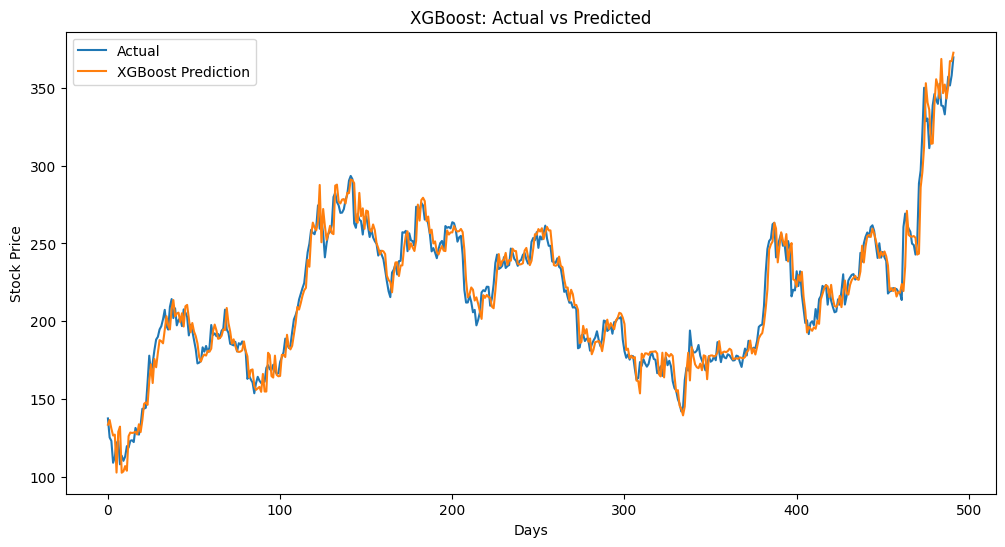

In [51]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')

plt.plot(xgb_pred, label='XGBoost Prediction')

plt.title("XGBoost: Actual vs Predicted")

plt.xlabel("Days")

plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [52]:
xgb_train_pred = xgb_model.predict(X_train)

train_r2 = r2_score(y_train, xgb_train_pred)

test_r2 = r2_score(y_test, xgb_pred)

print("Train R2:", train_r2)

print("Test R2:", test_r2)

Train R2: 0.9996114373207092
Test R2: 0.9563282132148743


In [53]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

            Feature  Importance
3               Low    0.650678
4             Close    0.218597
2              High    0.083867
1              Open    0.037258
10             MA_7    0.005135
16       Close_lag2    0.001901
15       Close_lag1    0.001029
8              year    0.000299
7             month    0.000268
11            MA_30    0.000184
9      Daily_Return    0.000160
14      Price_Range    0.000123
6               day    0.000116
12     Volatility_7    0.000115
13   is_quarter_end    0.000109
5   Intraday_change    0.000096
0            Volume    0.000065
